#Cross-Selling Assicurativo
**AssurePredict** è una compagnia di assicurazioni leader nel settore, specializzata nell'offrire soluzioni innovative per la gestione del rischio. Questo progetto mira a creare un modello predittivo in grado di individuare potenziali opportunità di **cross-selling** per clienti esistenti, identificando quelli che potrebbero essere interessati ad acquistare una polizza aggiuntiva per il loro veicolo.

#Obiettivo del Progetto
L'obiettivo è sviluppare un **modello di machine** learning che preveda se i clienti, che attualmente hanno un'assicurazione sanitaria, potrebbero essere interessati a sottoscrivere una polizza assicurativa per il loro veicolo. Il modello aiuterà **AssurePredict** a migliorare l'efficacia delle proprie strategie di cross-selling e ad aumentare la penetrazione nel mercato.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/insurance_cross_sell.csv"

In [ ]:
df = pd.read_csv(URL)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
print(f"Il dataset presenta {df.shape[0]} osservazioni con {df.shape[1]} features")

Il dataset presenta 381109 osservazioni con 12 features


In [ ]:
counts_na = df.isna().sum()
counts_na

,0
id,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0


Non sono presenti valori mancanti nel dataset.

---

Il dataset contiene informazioni dettagliate sui clienti e sul loro comportamento assicurativo. Le caratteristiche principali del dataset sono:

* id: identificativo univoco del cliente.
* Gender: sesso del cliente.
* Age: età del cliente.
* Driving_License: 1 se il cliente possiede la patente di guida, 0 altrimenti.
* Region_Code: codice univoco della regione di residenza del cliente.
* Previously_Insured: 1 se il cliente ha già un veicolo assicurato, 0 altrimenti.
* Vehicle_Age: età del veicolo del cliente.
* Vehicle_Damage: 1 se il cliente ha avuto incidenti o danni al veicolo in passato, 0 altrimenti.
* Annual_Premium: importo annuale del premio assicurativo pagato dal cliente.
* PolicySalesChannel: canale utilizzato per la vendita della polizza (es. email, telefono, di persona).
* Vintage: giorni da cui il cliente è assicurato con AssurePredict.
* Response: 1 se il cliente ha accettato la proposta di cross-sell, 0 altrimenti.

---

## Funzioni

In [ ]:
def plot_corr(df):
    corr = df.corr()

    sns.heatmap(corr,
                annot=True
                )
    plt.show()

In [ ]:
def plot_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    df_cm = pd.DataFrame(cm,
                         index=["Negative", "Positive"],
                         columns=["Predicted Negative", "Predicted Positive"])
    sns.heatmap(df_cm, annot=True, fmt="d")
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    plt.text(0.25, -0.1, f"Precision: {prec:.2f}", ha="center")
    plt.text(1.2, -0.1, f"Recall: {rec:.2f}", ha="center")
    plt.show()

## Preprocessing dei dati

In [ ]:
df = df.drop('id', axis=1)

In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Vehicle_Damage'] = le.fit_transform(df['Vehicle_Damage'])

In [ ]:
map_vehicle_age = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}
df['Vehicle_Age'] = df['Vehicle_Age'].map(lambda x: map_vehicle_age[x])

In [ ]:
df = pd.get_dummies(df, columns=['Policy_Sales_Channel'], prefix="Sales_Channel", prefix_sep="_")
df = pd.get_dummies(df, columns=['Region_Code'], prefix="Region", prefix_sep="_")
df.head()

,Gender,Age,Driving_License,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Vintage,Response,Sales_Channel_1.0,...,Region_43.0,Region_44.0,Region_45.0,Region_46.0,Region_47.0,Region_48.0,Region_49.0,Region_50.0,Region_51.0,Region_52.0
0,1,44,1,0,2,1,40454.0,217,1,False,...,False,False,False,False,False,False,False,False,False,False
1,1,76,1,0,1,0,33536.0,183,0,False,...,False,False,False,False,False,False,False,False,False,False
2,1,47,1,0,2,1,38294.0,27,1,False,...,False,False,False,False,False,False,False,False,False,False
3,1,21,1,1,0,0,28619.0,203,0,False,...,False,False,False,False,False,False,False,False,False,False
4,0,29,1,1,0,0,27496.0,39,0,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#visualizziamo quante colonne abbiamo creato con pd.get_dummies
df.shape[1] - 8

209

## 1. Esplorazione del Dataset
L'esplorazione preliminare del dataset permetterà di comprendere meglio la distribuzione delle caratteristiche e delle variabili target.

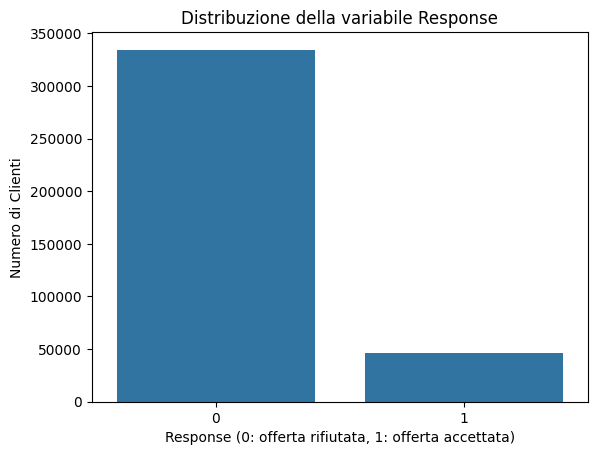

In [ ]:
sns.countplot(x='Response', data=df)
plt.title("Distribuzione della variabile Response")
plt.ylabel("Numero di Clienti")
plt.xlabel("Response (0: offerta rifiutata, 1: offerta accettata)")
plt.show()

In [ ]:
print(f"Clienti che hanno accettato la proposta di cross-sell: {round(df['Response'].value_counts()[1]/df.shape[0]*100, 2)}%")
print(f"Clienti che non hanno accettato la proposta di cross-sell: {round(df['Response'].value_counts()[0]/df.shape[0]*100, 2)}%")

Clienti che hanno accettato la proposta di cross-sell: 12.26%
Clienti che non hanno accettato la proposta di cross-sell: 87.74%


Possiamo vedere che all'interno del dataset che c'è un forte sbilanciamento per la variabile Response, nello specifico poche persone accettano l'offerta di cross-sell.

Andando più in profondità possiamo vedere graficamente le relazioni presenti tra il target Response e le altre variabili, come le variabili chiave Annual Premium, Vehicle Age e Previously Insured.

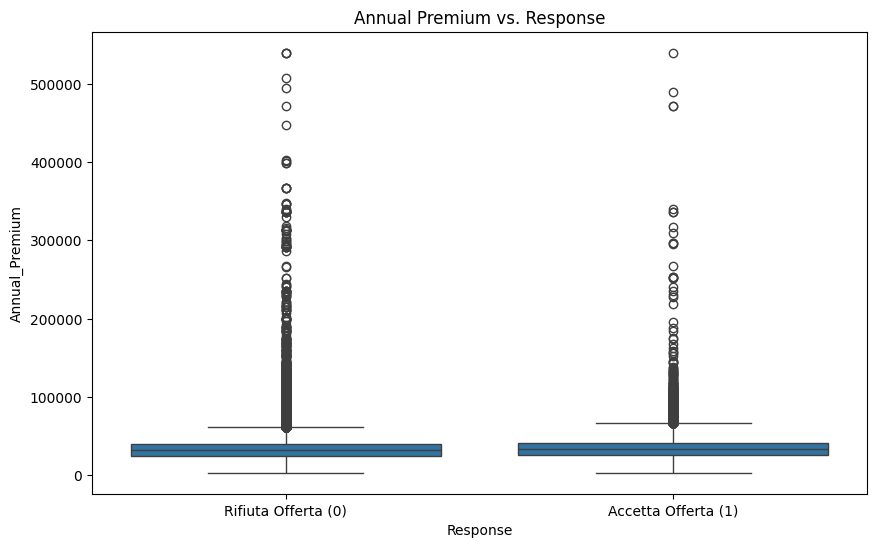

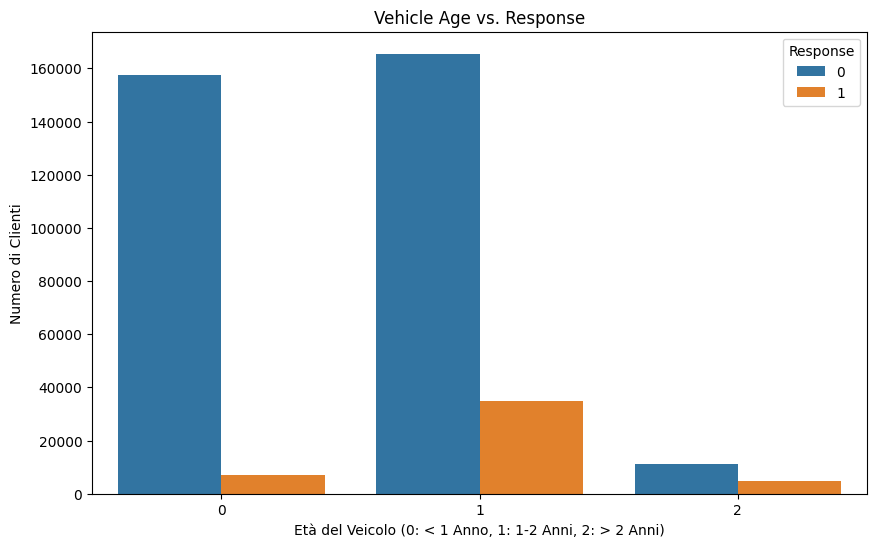

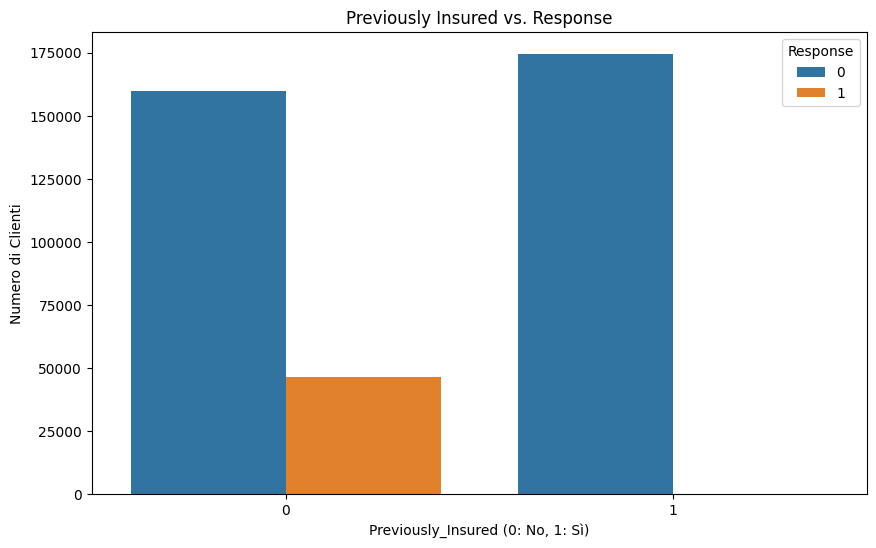

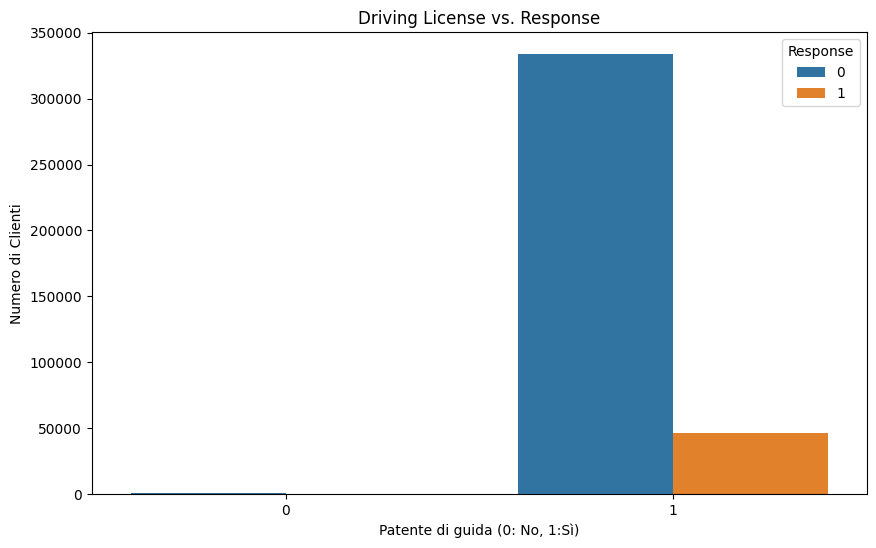

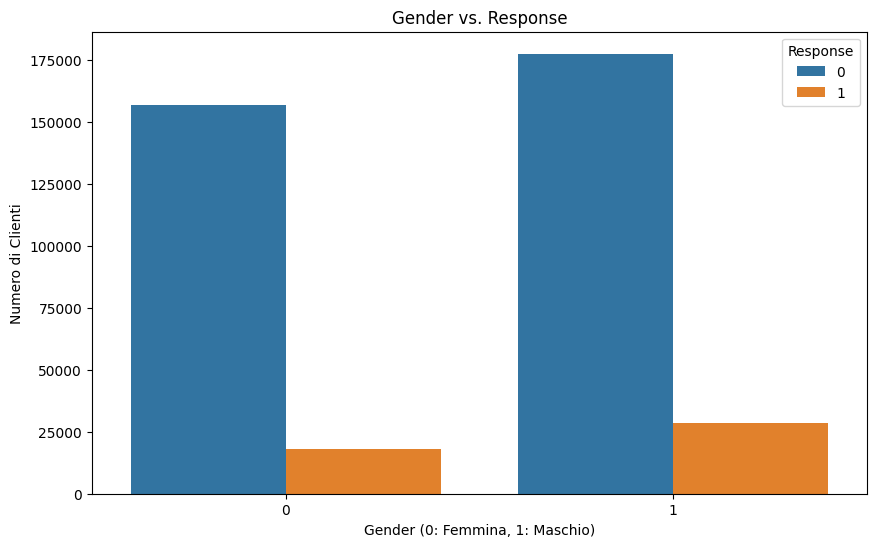

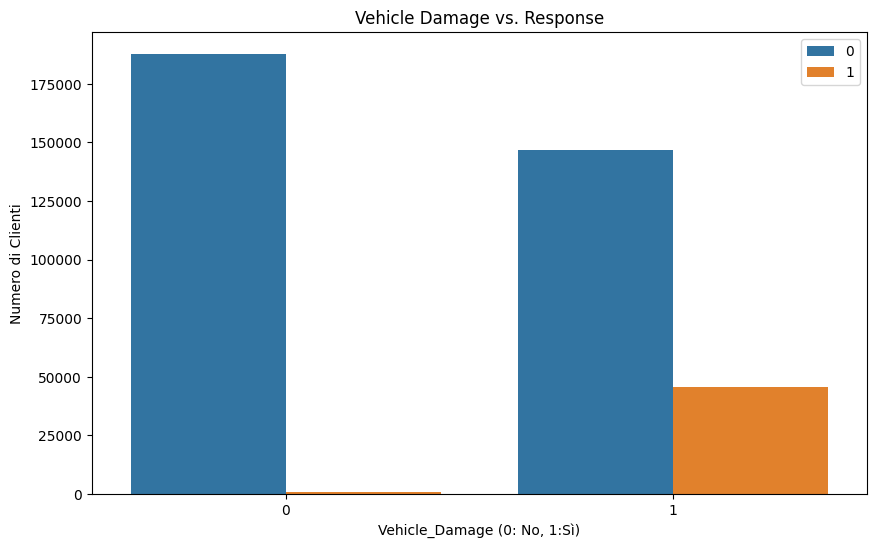

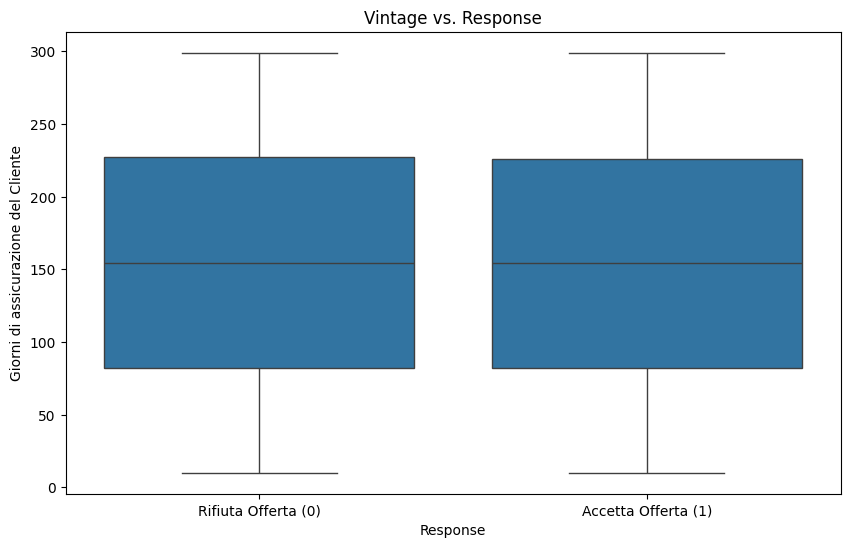

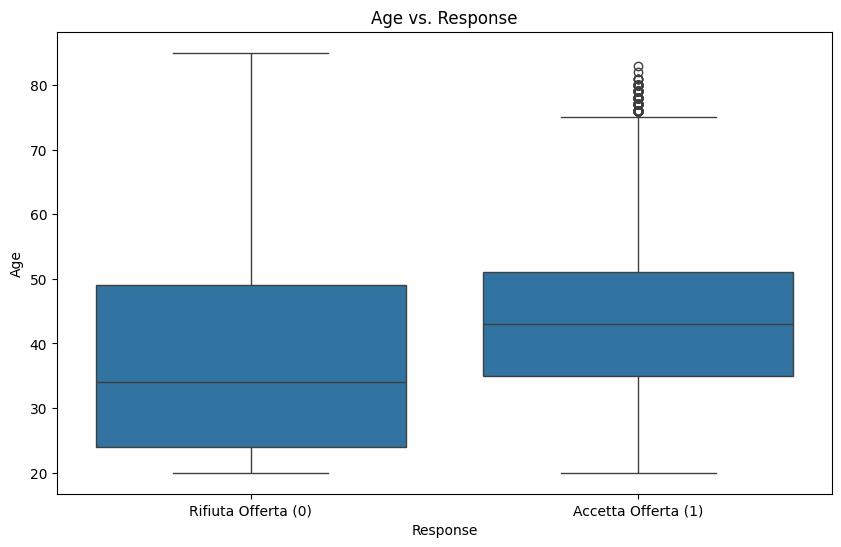

In [ ]:
# Relazione tra Annual Premium e Response
plt.figure(figsize=(10, 6))
sns.boxplot(x='Response', y='Annual_Premium', data=df)
plt.title('Annual Premium vs. Response')
plt.xlabel('Response')
plt.ylabel('Annual_Premium')
plt.xticks(ticks=[0, 1], labels=['Rifiuta Offerta (0)', 'Accetta Offerta (1)'])
plt.show()

# Relazione tra Vehicle Age e Response
plt.figure(figsize=(10, 6))
sns.countplot(x='Vehicle_Age', hue='Response', data=df)
plt.title('Vehicle Age vs. Response')
plt.xlabel('Età del Veicolo (0: < 1 Anno, 1: 1-2 Anni, 2: > 2 Anni)')
plt.ylabel('Numero di Clienti')
plt.legend(title='Response')
plt.show()

# Relazione tra Previously Insured e Response
plt.figure(figsize=(10, 6))
sns.countplot(x='Previously_Insured', hue='Response', data=df)
plt.title('Previously Insured vs. Response')
plt.xlabel('Previously_Insured (0: No, 1: Sì)')
plt.ylabel('Numero di Clienti')
plt.legend(title='Response')
plt.show()

# Relazione tra Driving License e Response
plt.figure(figsize=(10, 6))
sns.countplot(x='Driving_License', hue='Response', data=df)
plt.title('Driving License vs. Response')
plt.xlabel('Patente di guida (0: No, 1:Sì)')
plt.ylabel('Numero di Clienti')
plt.legend(title='Response')
plt.show()

# Relazione tra Gender e Response
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender', hue='Response', data=df)
plt.title('Gender vs. Response')
plt.xlabel('Gender (0: Femmina, 1: Maschio)')
plt.ylabel('Numero di Clienti')
plt.legend(title='Response')
plt.show()

# Relazione tra Vehicle_Damage e Response
plt.figure(figsize=(10, 6))
sns.countplot(x='Vehicle_Damage', hue='Response', data=df)
plt.title('Vehicle Damage vs. Response')
plt.xlabel('Vehicle_Damage (0: No, 1:Sì)')
plt.ylabel('Numero di Clienti')
plt.legend()
plt.show()

# Relazione tra Vintage e Response
plt.figure(figsize=(10, 6))
sns.boxplot(x='Response', y='Vintage', data=df)
plt.title('Vintage vs. Response')
plt.xlabel('Response')
plt.ylabel('Giorni di assicurazione del Cliente')
plt.xticks(ticks=[0, 1], labels=['Rifiuta Offerta (0)', 'Accetta Offerta (1)'])
plt.show()

# Relazione tra Age e Response
plt.figure(figsize=(10, 6))
sns.boxplot(x='Response', y='Age', data=df)
plt.title('Age vs. Response')
plt.xlabel('Response')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['Rifiuta Offerta (0)', 'Accetta Offerta (1)'])
plt.show()

* Dal boxplot Annual Premium vs Response possiamo vedere che non ci sono differenze sostanziali tra chi accetta o rifiuta l'offerta, facendo pensare che Annual Premium abbia una scarsa importanza ai fini predittivi per il modello che andremo a creare.

* Dal grafico a barre Previously Insured vs Response possiamo notare che chi è stato precedentemente assicurato non tende ad accettare la proposta di cross-sell.

* Dal grafico a barre Driving License vs Response, possiamo notare che ovviamente solo chi ha una patente di guida tende ad accettare la proposta.

* Dal grafico a barre Vehicle Age vs Response possiamo notare una tendenza superiore ad accettare la proposta per quei clienti che possiedono un auto da 1-2 anni.

* Dal grafico a barre Gender vs Response non sembrano esserci differenze sostanziali per chi accetta o rifiuta l'offerta tra Femmina e Maschio.

* Dal grafico Vehicle Damage vs Response come potevamo aspettarci, possiamo notare che i clienti che hanno subito qualche danno al veicolo in passato tendono ad accettare la proposta.

* Dal boxplot Vintage vs Response non si notano differenze sostanziali che dipendono dai giorni in cui il cliente è assicurato, indicando probabilmente che Vintage non è una variabile indicativa.

* Dal boxplot Age vs Response si nota che le persone più giovani tendono a rifiutare maggiormente l'offerta di cross-sell.

Adesso una cosa che possiamo fare per comprendere meglio le relazioni tra le variabili chiave citate sopra, è calcolare la matrice di correlazione:

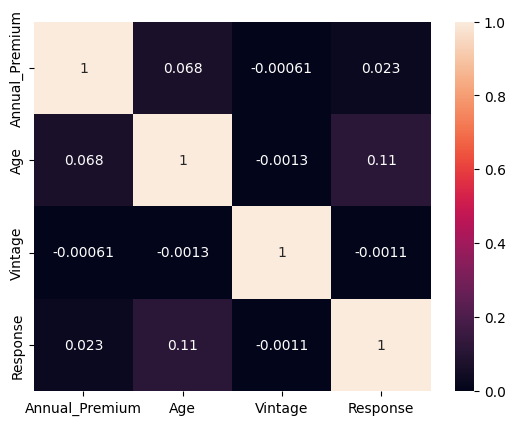

In [ ]:
plot_corr(df[['Annual_Premium', 'Age', 'Vintage', 'Response']])

Possiamo vedere che Response non sembra correlata linearmente con le variabili Annual_Premium e Vintage e presenta una lieve correlazione positiva con Age.

Togliamo dal modello le variabili che sembrano poco informative, ovvero: Gender, Vintage e Annual_Premium. Questa decisione è motivata anche da test effettuati sui modelli che vedremo, e che mostravano come queste variabili non fossero rilevanti ai fini predittivi del modello.

In [ ]:
df = df.drop(['Vintage','Annual_Premium', 'Gender'], axis=1)

Dall'analisi esplorativa quello che possiamo dire è che potrebbe esserci una mancanza di un segnale forte e chiaro nelle features attuali per prevedere efficacemente la Response. Infatti se le variabili disponibili non contengono informazioni distintive o non sono sufficientemente correlate con la propensione del cliente ad accettare l'offerta, anche il modello più sofisticato farà fatica a identificare pattern predittivi robusti. Le osservazioni dei grafici e le correlazioni lineari deboli o assenti tra Response e alcune variabili suggeriscono questo.
Inoltre Response è fortemente sbilanciata, con una netta prevalenza di clienti che rifiutano l'offerta rispetto a quelli che l'accettano. Nonostante l'adozione di tecniche di ribilanciamento (come l'undersampling, class_weight o una combinazione di over/undersampling), uno sbilanciamento così marcato pone una sfida intrinseca, ma andiamo a verificarlo nel concreto.

##2. Gestione dello Sbilanciamento delle Classi e creazione dei Modelli


In [ ]:
# Andiamo a costruirci features e target dal dataset
X, y = df.drop('Response', axis=1), df['Response']
X.shape, y.shape

((381109, 213), (381109,))

In [ ]:
# Suddividiamo in set per l'addestramento e set per il test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
print(f"Il train set contiene {X_train.shape[0]} osservazioni con {X_train.shape[1]} features")
print(f"Il test set contiene {X_test.shape[0]} osservazioni con {X_test.shape[1]} features")

Il train set contiene 304887 osservazioni con 213 features
Il test set contiene 76222 osservazioni con 213 features


---

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score, log_loss

Proseguiamo testando e confrontando i modelli relativi a tecniche di bilanciamento diverso. Nello specifico si adotterà un modello di Regressione Logistica, ovvero un modello di classificazione, con metodi di bilanciamento delle classi come Class_Weight, UnderSampling e OverSampling. La valutazione dei singoli e il confronto tra i vari modelli verrà fatto attraverso la cross-validation per essere più precisi possibile.

In [ ]:
# Qui possiamo inserire facilmente le variabili numeriche da scalare
preprocessor = ColumnTransformer(
    [("scaler", StandardScaler(), ['Age'])],
    remainder="passthrough"
)

# --- Metriche da Valutare ---
scoring = {
    'precision_1': make_scorer(precision_score, pos_label=1),
    'recall_1': make_scorer(recall_score, pos_label=1),
    'f1_1': make_scorer(f1_score, pos_label=1),
    'accuracy_1': make_scorer(accuracy_score),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# --- Pipelines dei Modelli ---

# Modello 1: senza bilanciamento
pipeline_no_balance = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Modello 2: class_weight
pipeline_class_weight = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42, max_iter=1000))
])

# Modello 3: Oversampling (SMOTE)
pipeline_oversampling = ImbPipeline([
    ('preprocessor', preprocessor),
    ('oversampler', SMOTE(sampling_strategy=0.20, random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

# Modello 4: Undersampling
pipeline_undersampling = ImbPipeline([
    ('preprocessor', preprocessor),
    ('undersampler', RandomUnderSampler(sampling_strategy=0.4, random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

# Modello 5: Oversampling + Undersampling
pipeline_over_under_sampling = ImbPipeline([
    ('preprocessor', preprocessor),
    ('oversampler', SMOTE(sampling_strategy=0.18, random_state=42)),
    ('undersampler', RandomUnderSampler(sampling_strategy=0.4, random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

In [ ]:
print("--- Valutazione Modello senza bilanciamento ---")
scores_no_balance = cross_validate(pipeline_no_balance, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in scores_no_balance.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("--- Valutazione Modello: class_weight ---")
scores_class_weight = cross_validate(pipeline_class_weight, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in scores_class_weight.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("\n--- Valutazione Modello: Oversampling (SMOTE) ---")
scores_oversampling = cross_validate(pipeline_oversampling, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in scores_oversampling.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("\n--- Valutazione Modello: Undersampling ---")
scores_undersampling = cross_validate(pipeline_undersampling, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in scores_undersampling.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("\n--- Valutazione Modello: Oversampling + Undersampling ---")
scores_over_under_sampling = cross_validate(pipeline_over_under_sampling, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in scores_over_under_sampling.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

Adesso proviamo i modelli che sono sembrati migliori durante la cross-validation, sfruttando il train set e il test set iniziali.

Il modello con Class_Weight, il modello con Undersampling e quello che unisce Oversampling con Undersampling sembrano performare meglio, al contrario, non gestire per niente il bilanciamento o gestirlo solo attraverso OverSampling non sembra una buona scelta.

* Tuning del modello: **UnderSampling**

In [ ]:
#UnderSampling
under = RandomUnderSampler(sampling_strategy=0.6, random_state=42)
X_under, y_under = under.fit_resample(X_train, y_train)

print(Counter(y_train))
print(Counter(y_under))

Counter({0: 267519, 1: 37368})
Counter({0: 62280, 1: 37368})


Dovo varie prove i parametri di regolarizzazione che sembrano portare ai migliori risultati sono C=0.01 e penalty='l2' con solver='liblinear'

In [ ]:
modelUS = LogisticRegression(solver='liblinear', C=0.01, penalty='l1', max_iter=1000)
modelUS.fit(X_under, y_under)

LogisticRegression(C=0.01, max_iter=1000, penalty='l1', solver='liblinear')

In [ ]:
y_pred_train_US = modelUS.predict(X_under)
y_pred_test_US = modelUS.predict(X_test)

y_proba_train_US = modelUS.predict_proba(X_under)
y_proba_test_US = modelUS.predict_proba(X_test)

In [ ]:
print(classification_report(y_under, y_pred_train_US, target_names=['No Response (0)', 'Response (1)']))
print("-"*60)
print(classification_report(y_test, y_pred_test_US))

                 precision    recall  f1-score   support

No Response (0)       0.89      0.72      0.80     62280
   Response (1)       0.65      0.85      0.74     37368

       accuracy                           0.77     99648
      macro avg       0.77      0.79      0.77     99648
   weighted avg       0.80      0.77      0.77     99648

------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     66880
           1       0.30      0.86      0.44      9342

    accuracy                           0.74     76222
   macro avg       0.64      0.79      0.64     76222
weighted avg       0.89      0.74      0.78     76222



Il modello con Undersampling tende a overfittare nonostante il tipo di regolarizzazione L1 e un parametro C abbastanza basso.

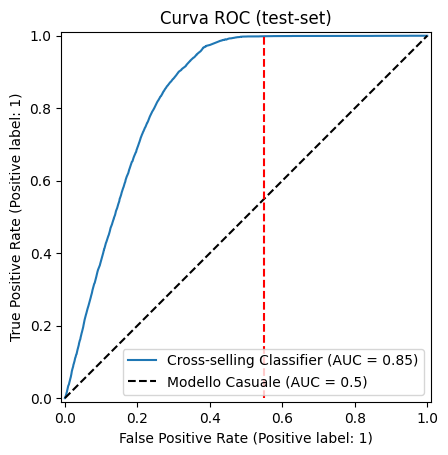

In [ ]:
RocCurveDisplay.from_estimator(modelUS, X_test, y_test, name="Cross-selling Classifier")
plt.plot([0,1], [0,1], "k--", label="Modello Casuale (AUC = 0.5)")
plt.title("Curva ROC (test-set)")

#plot di una linea verticale che passa dove il trade off tra FPR e TPR è migliore
plt.vlines(x=0.55, ymin=0, ymax=1, linestyles='dashed', colors='red')

plt.legend()
plt.show()

Proviamo a gestire meglio la soglia di validazione

In [ ]:
y_pred_test_US = np.where(y_proba_test_US[:,1] > 0.55, 1, 0)

In [ ]:
print(classification_report(y_test, y_pred_test_US))

              precision    recall  f1-score   support

           0       0.96      0.75      0.85     66880
           1       0.31      0.80      0.45      9342

    accuracy                           0.76     76222
   macro avg       0.64      0.78      0.65     76222
weighted avg       0.88      0.76      0.80     76222



* Tuning del modello: **Class_Weight**

Dovo varie prove i parametri di regolarizzazione che sembrano portare ai migliori risultati sono C=0.5 e penalty='l1' e solver='liblinear'

In [ ]:
modelCW = LogisticRegression(class_weight='balanced', solver='liblinear', C=0.5, penalty='l1', max_iter=1000)
modelCW.fit(X_train, y_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000, penalty='l1',
                   solver='liblinear')

In [ ]:
y_train_pred_CW = modelCW.predict(X_train)
y_test_pred_CW = modelCW.predict(X_test)

y_train_proba_CW = modelCW.predict_proba(X_train)
y_test_proba_CW = modelCW.predict_proba(X_test)

In [ ]:
print(classification_report(y_train, y_train_pred_CW, target_names=['No Response (0)', 'Response (1)']))
print("-"*60)
print(classification_report(y_test, y_test_pred_CW))

                 precision    recall  f1-score   support

No Response (0)       0.99      0.66      0.79    267519
   Response (1)       0.28      0.94      0.43     37368

       accuracy                           0.69    304887
      macro avg       0.63      0.80      0.61    304887
   weighted avg       0.90      0.69      0.75    304887

------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     66880
           1       0.28      0.94      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222



Il modello con Class_Weight sembra non overfittare e inoltre tende ad avere un'alta Recall ma bassa Precision. Proviamo quindi a modulare leggeremente la Decision Boundery, cercando di aumentare leggermente la Precison senza perdere troppa Recall, che è una metrica importantissima per non perdere potenziali clienti che accettono la proposta di Cross-Sell.

La curva ROC ci potrebbe dare un grande aiuto visivo:

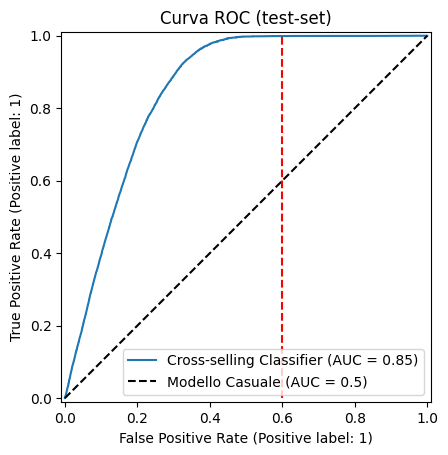

In [ ]:
RocCurveDisplay.from_estimator(modelCW, X_test, y_test, name="Cross-selling Classifier")
plt.plot([0,1], [0,1], "k--", label="Modello Casuale (AUC = 0.5)")
plt.title("Curva ROC (test-set)")

#plot di una linea verticale che passa dove il trade off tra FPR e TPR è migliore
plt.vlines(x=0.60, ymin=0, ymax=1, linestyles='dashed', colors='red')

plt.legend()
plt.show()

In [ ]:
y_test_pred_CW = np.where(y_test_proba_CW[:,1] > 0.60, 1, 0)

In [ ]:
print(classification_report(y_test, y_test_pred_CW))

              precision    recall  f1-score   support

           0       0.97      0.72      0.83     66880
           1       0.30      0.86      0.45      9342

    accuracy                           0.74     76222
   macro avg       0.64      0.79      0.64     76222
weighted avg       0.89      0.74      0.78     76222



* Tuning del modello: **OverSampling + UnderSampling**

In [ ]:
over = SMOTE(sampling_strategy=0.20, random_state=42)
X_over, y_over = over.fit_resample(X_train, y_train)

under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_under, y_under = under.fit_resample(X_over, y_over)


print(Counter(y_train))
print(Counter(y_over))
print(Counter(y_under))

Counter({0: 267519, 1: 37368})
Counter({0: 267519, 1: 53503})
Counter({0: 107006, 1: 53503})


Dovo varie prove i parametri di regolarizzazione che sembrano portare ai migliori risultati sono penalty='l2', solver='liblinear' e il parametro di regolarizzazione non viene modificato (C=1)

In [ ]:
modelU_O = LogisticRegression(solver='liblinear', penalty='l1', max_iter=1000)
modelU_O.fit(X_under, y_under)

LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

In [ ]:
y_train_pred_U_O = modelU_O.predict(X_under)
y_test_pred_U_O = modelU_O.predict(X_test)

y_train_proba_U_O = modelU_O.predict_proba(X_under)
y_test_proba_U_O = modelU_O.predict_proba(X_test)

In [ ]:
print(classification_report(y_under, y_train_pred_U_O, target_names=['No Response (0)', 'Response (1)']))
print("-"*60)
print(classification_report(y_test, y_test_pred_U_O))

                 precision    recall  f1-score   support

No Response (0)       0.87      0.78      0.82    107006
   Response (1)       0.63      0.77      0.69     53503

       accuracy                           0.77    160509
      macro avg       0.75      0.77      0.76    160509
   weighted avg       0.79      0.77      0.78    160509

------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     66880
           1       0.32      0.75      0.45      9342

    accuracy                           0.78     76222
   macro avg       0.64      0.77      0.65     76222
weighted avg       0.88      0.78      0.81     76222



Anche il modello con Oversampling + UnderSampling tende ad overfittare

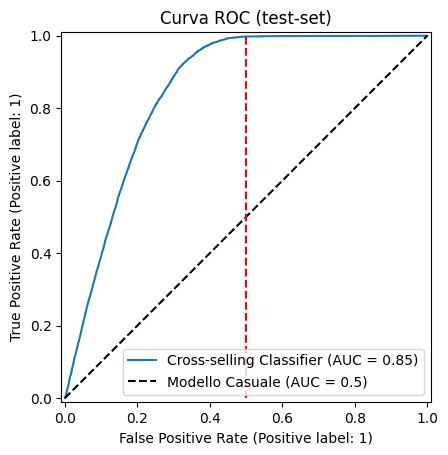

In [ ]:
RocCurveDisplay.from_estimator(modelU_O, X_test, y_test, name="Cross-selling Classifier")
plt.plot([0,1], [0,1], "k--", label="Modello Casuale (AUC = 0.5)")
plt.title("Curva ROC (test-set)")

#plot di una linea verticale che passa dove il trade off tra FPR e TPR è migliore
plt.vlines(x=0.50, ymin=0, ymax=1, linestyles='dashed', colors='red')

plt.legend()
plt.show()

In [ ]:
y_test_pred_U_O = np.where(y_test_proba_U_O[:,1] > 0.55, 1, 0)

In [ ]:
print(classification_report(y_test, y_test_pred_U_O))

              precision    recall  f1-score   support

           0       0.94      0.82      0.88     66880
           1       0.34      0.64      0.44      9342

    accuracy                           0.80     76222
   macro avg       0.64      0.73      0.66     76222
weighted avg       0.87      0.80      0.82     76222



Il modello con Class_Weight sembra essere il migliore per questa casistica, avendo una buona Recall che è importantissima per non perdere occasioni di mercato. Gli altri due modelli (Undersampling e OverSampling+UnderSampling) potrebbero soffrire di overfitting, quindi anche se sembrano bilanciare meglio precision e recall si sconsiglia l'utilizzo.

Al termine di questo progetto, dopo aver implementato diverse strategie di preprocessing, ribilanciamento e ottimizzazione del modello di Regressione Logistica, inclusi il fine-tuning della regolarizzazione (C) e del tipo di penalità (l1/l2), abbiamo osservato che le prestazioni del modello sembrano raggiungere un limite intrinseco dettato probabilmente dalla natura dei dati attuali.

Nonostante un buon ROC AUC di 0.85  (indicativo di una discreta capacità discriminatoria), il modello finale scelto ha mostrato una performance sul test set con un F1-score di 0.45, una Precisione di circa 0.30-0.31 e una Recall di 0.81-0.86. Questi valori, suggeriscono che il potenziale di miglioramento con le sole feature disponibili potrebbe essere limitato.

Le principali ragioni di questa saturazione delle performance sono da ricercarsi quindi, come avevamo previsto nelle analisi iniziali, in specifici fattori legati al dataset, ovvero al problema di sbilanciamento elevato delle classi, al probabile debole impatto predittivo delle features e anche ovviamente dalla complessità del problema che si sta trattando.

Inoltre l'uso della Regressione Logistica, che è un modello lineare, potrebbe non essere sufficiente a catturare relazioni non lineari o interazioni complesse tra le caratteristiche e la probabilità di risposta, qualora queste esistessero e fossero significative per la predizione.



Per superare queste limitazioni e migliorare ulteriormente la capacità di AssurePredict di individuare opportunità di cross-selling, una raccomandazione che si potrebbe fare è sicuramente l'arricchimento del Dataset: acquisizione di nuovi dati, quindi integrare il dataset con nuove fonti di dati che possano catturare le variabili latenti. Per esempio dati socio-demografici più dettagliati, o informazioni su fattori esterni rilevanti.
Questi nuovi dati, che possono anche essere ottenuti proponendo l'assicurazione alle persone risultanti dal modello attuale, potranno essere utilizzati per migliorare il modello stesso.


